## Pertpy cell type priorization with Augur

This script was to generate the mean augur score for cell types at level_2 annotation comparing IPF mild vs Control.

In [1]:
import scanpy as sc
import pertpy as pt
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import rcParams

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3               
sc.logging.print_version_and_date()

# making sure plots & clusters are reproducible
np.random.seed(42)

/home/huijuanwang/miniconda3/envs/milopy/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/huijuanwang/miniconda3/envs/milopy/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/huijuanwang/miniconda3/envs/milopy/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/huijuanwang/miniconda3/envs/milopy/lib/python3.11/site-packages/pytorch_lightning/utilities/imports.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package

Running Scanpy 1.11.4, on 2026-08-27 09:21.


In [2]:
## plotting variables
plot_folder = "/media/synology/Huijuan/Plots/IPF_subsets/Augurpy/"
sc.set_figure_params(vector_friendly = True)
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['pdf.fonttype'] = 42

In [3]:
object_folder = "/media/HDD_1/sc_data_objects/FibFoci/"
adata = sc.read(object_folder + "18082026_snRNA_IPF_annotation_final.h5ad") 
adata

AnnData object with n_obs × n_vars = 63072 × 31116
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'souporcell_assignment', 'souporcell_singlet_posterior', 'souporcell_doublet_posterior', 'souporcell_log_prob_singleton', 'souporcell_log_prob_doublet', 'souporcell_cluster0', 'souporcell_cluster1', 'souporcell_cluster2', 'ident', 'sum', 'detected', 'subsets_Ribo_sum', 'subsets_Ribo_detected', 'subsets_Ribo_percent', 'total', 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', '_scvi_batch', '_scvi_labels', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'S.Score', 'G2M.Score', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'souporcell_cluster3', 'sex', 'batch', 'Level_1', 'Level_2', 'Level_3', 'cell_type', 'severity', 'name', 'meta', 'ashcroft score', 'fibrosis extent', 'surface density'
    var: 'name', 'highly_variable', 

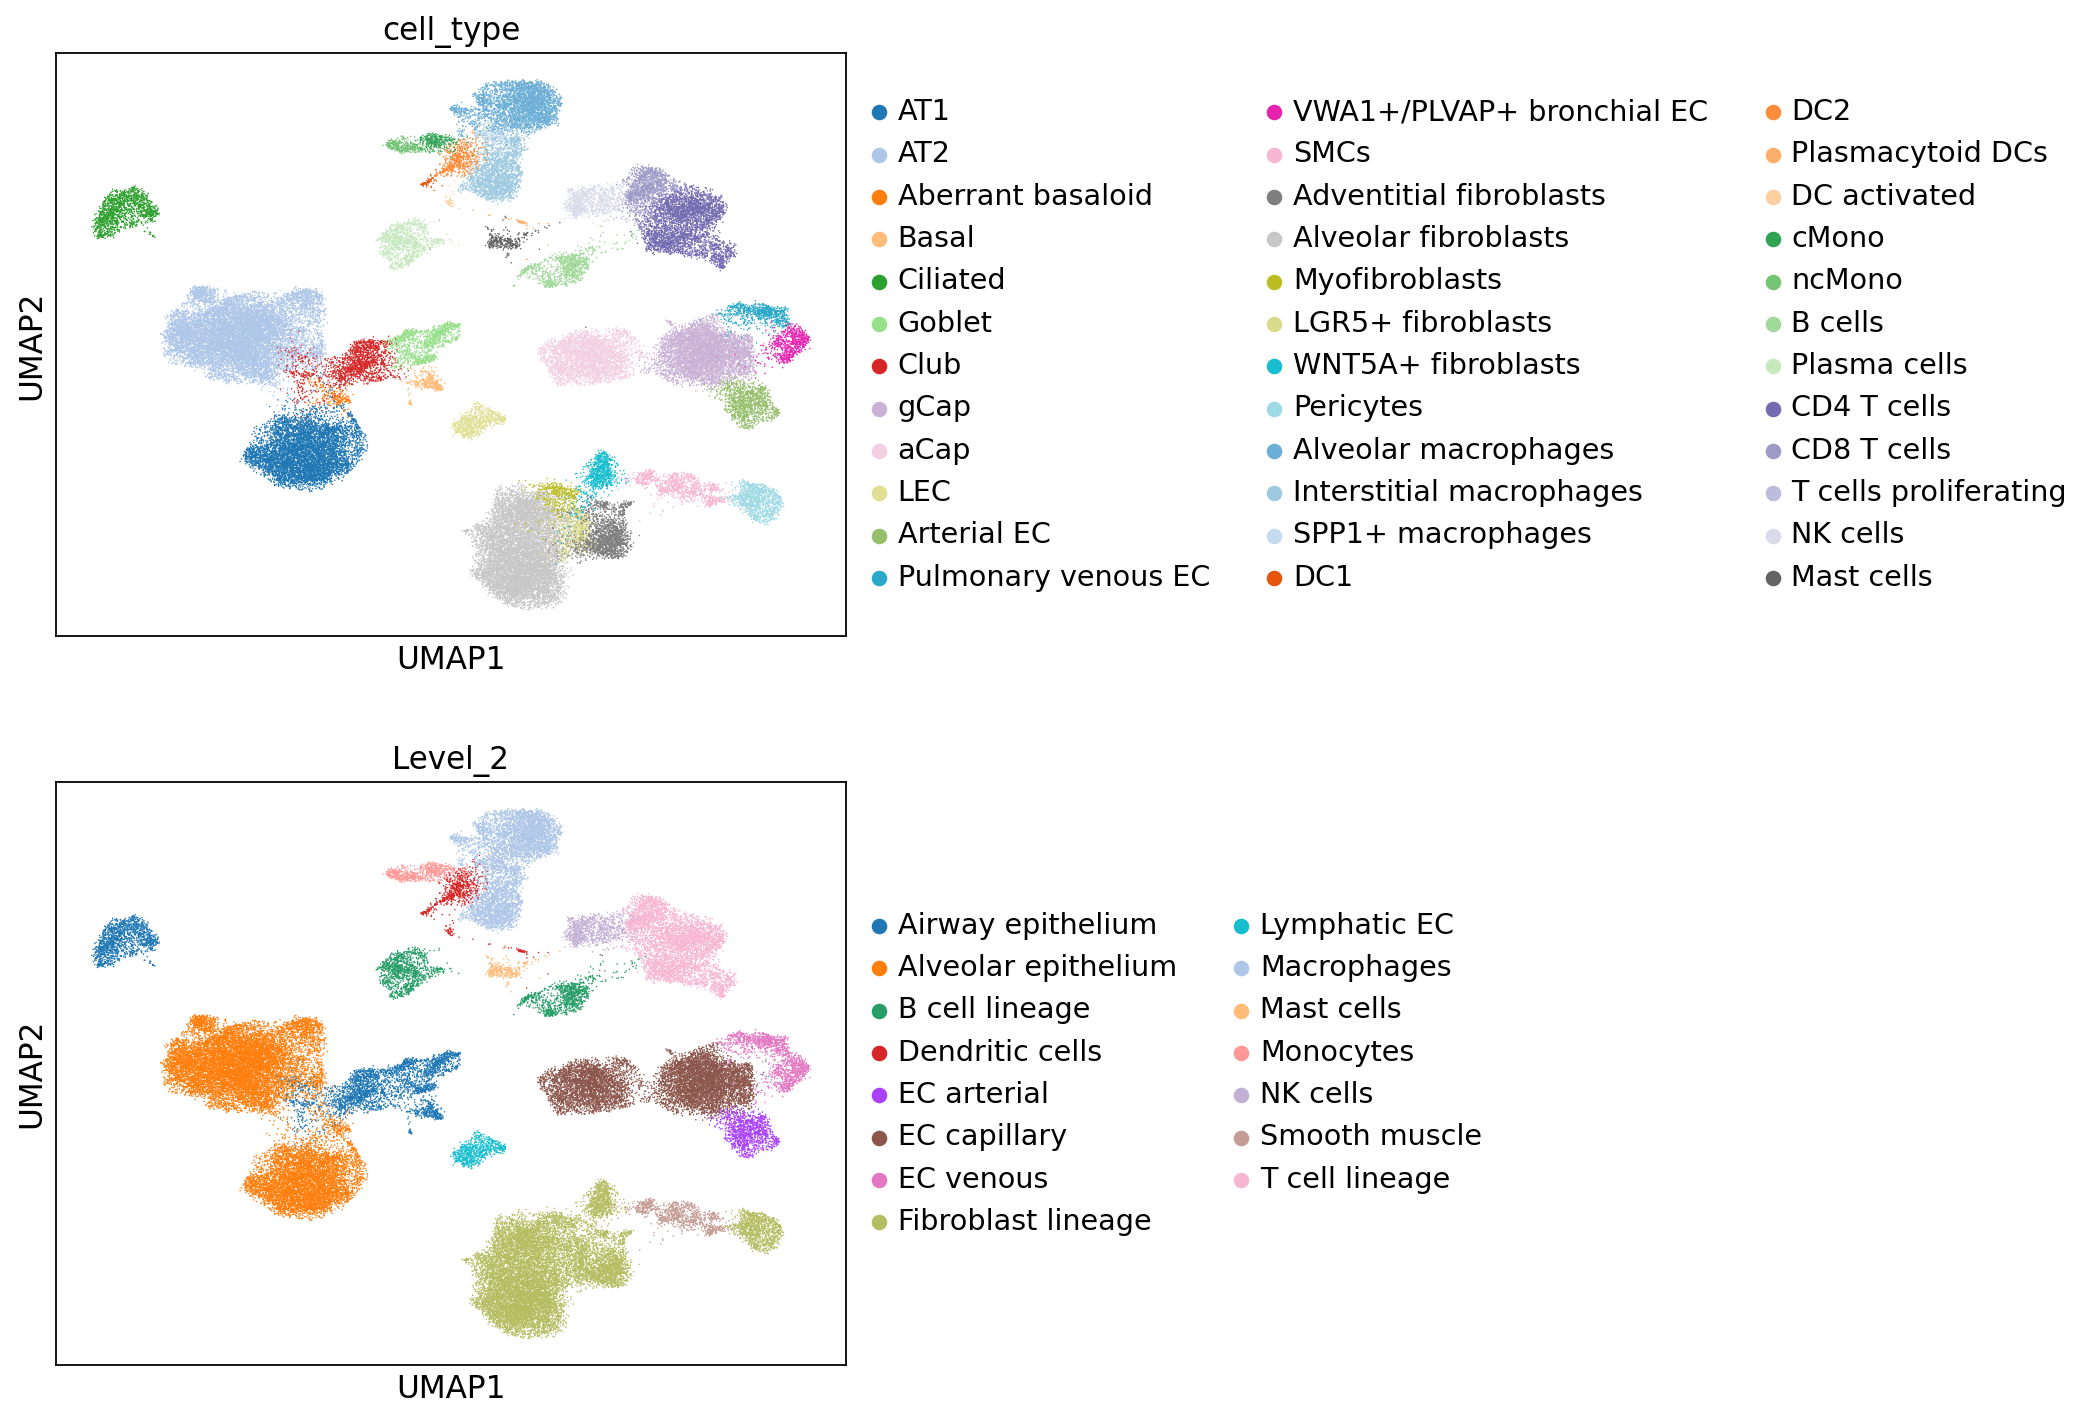

In [4]:
## overview UMAPs
sc.pl.umap(adata, color = ['cell_type', 'Level_2'], ncols = 1)

In [5]:
pd.crosstab(adata.obs['severity'],adata.obs['cell_type'])

cell_type,AT1,AT2,Aberrant basaloid,Basal,Ciliated,Goblet,Club,gCap,aCap,LEC,...,DC activated,cMono,ncMono,B cells,Plasma cells,CD4 T cells,CD8 T cells,T cells proliferating,NK cells,Mast cells
severity,,,,,,,,,,,,,,,,,,,,,
Control,3779,6253,0,81,299,154,252,2781,1443,337,...,11,185,194,52,178,783,222,7,454,113
IPFMild,2061,3882,71,59,441,338,204,1783,1526,202,...,5,94,134,88,209,1100,269,19,338,56
IPFSevere,450,1154,125,186,644,640,1160,400,214,184,...,22,32,8,859,725,1593,734,15,137,132


In [6]:
pd.crosstab(adata.obs['severity'],adata.obs['Level_2'])

Level_2,Airway epithelium,Alveolar epithelium,B cell lineage,Dendritic cells,EC arterial,EC capillary,EC venous,Fibroblast lineage,Lymphatic EC,Macrophages,Mast cells,Monocytes,NK cells,Smooth muscle,T cell lineage
severity,,,,,,,,,,,,,,,
Control,786,10032,230,242,630,4224,455,4591,337,2172,113,379,454,279,1012
IPFMild,1042,6014,297,255,318,3309,479,4674,202,1968,56,228,338,184,1388
IPFSevere,2630,1729,1584,229,188,614,490,4187,184,1393,132,40,137,505,2342


In [7]:
adata.obs.rename(columns = {'cell_type': 'cell_type_resolved'}, inplace=True)

In [8]:
adata = adata[~adata.obs.Level_2.isin(['Rare'])].copy()

In [9]:
## random forest classifier for categorical 'age_treatment' variable
ag_rfc = pt.tl.Augur("random_forest_classifier")

In [10]:
adata = adata[adata.obs.severity.isin(['Control','IPFSevere'])].copy()

In [11]:
adata.obs.severity.value_counts()

severity
Control      25936
IPFSevere    16384
Name: count, dtype: int64

In [12]:
loaded_data = ag_rfc.load(adata, label_col="severity", cell_type_col="Level_2")
loaded_data

AnnData object with n_obs × n_vars = 42320 × 31116
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'souporcell_assignment', 'souporcell_singlet_posterior', 'souporcell_doublet_posterior', 'souporcell_log_prob_singleton', 'souporcell_log_prob_doublet', 'souporcell_cluster0', 'souporcell_cluster1', 'souporcell_cluster2', 'ident', 'sum', 'detected', 'subsets_Ribo_sum', 'subsets_Ribo_detected', 'subsets_Ribo_percent', 'total', 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', '_scvi_batch', '_scvi_labels', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'S.Score', 'G2M.Score', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'souporcell_cluster3', 'sex', 'batch', 'Level_1', 'cell_type', 'Level_3', 'cell_type_resolved', 'label', 'name', 'meta', 'ashcroft score', 'fibrosis extent', 'surface density', 'y_'
    var: 'name', 'high

In [13]:
loaded_data.var['name'] = loaded_data.var_names

In [14]:
v_adata, v_results = ag_rfc.predict(
    loaded_data, n_subsamples=17, subsample_size=20, n_threads=32, select_variance_features=True)

v_results["summary_metrics"]

! Set smaller span value in the case of a `segmentation fault` error.
! Set larger span in case of svddc or other near singularities error.


Output()

/home/huijuanwang/miniconda3/envs/milopy/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/huijuanwang/miniconda3/envs/milopy/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/huijuanwang/miniconda3/envs/milopy/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/huijuanwang/miniconda3/envs/milopy/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/

,Fibroblast lineage,Alveolar epithelium,Airway epithelium,T cell lineage,EC capillary,Macrophages,B cell lineage,EC venous,Dendritic cells,Smooth muscle,NK cells,EC arterial,Lymphatic EC,Mast cells,Monocytes
mean_augur_score,0.761738,0.744198,0.586001,0.749066,0.862678,0.664266,0.719688,0.746065,0.579465,0.647359,0.767807,0.768274,0.665666,0.691477,0.685374
mean_auc,0.761738,0.744198,0.586001,0.749066,0.862678,0.664266,0.719688,0.746065,0.579465,0.647359,0.767807,0.768274,0.665666,0.691477,0.685374
mean_accuracy,0.653954,0.647813,0.537169,0.602349,0.624111,0.578755,0.639410,0.648567,0.531028,0.597285,0.625189,0.646197,0.603641,0.589205,0.592437
mean_precision,0.704766,0.660043,0.520694,0.707781,0.813725,0.574851,0.771467,0.727451,0.535924,0.634541,0.777124,0.732563,0.641979,0.677482,0.728291
mean_f1,0.606504,0.641173,0.509845,0.402478,0.392240,0.614320,0.479695,0.534245,0.420906,0.487104,0.456436,0.554495,0.520098,0.400758,0.398089
mean_recall,0.592904,0.683473,0.556022,0.317927,0.281979,0.717087,0.382353,0.465920,0.397292,0.454715,0.351074,0.485528,0.497666,0.319795,0.307190


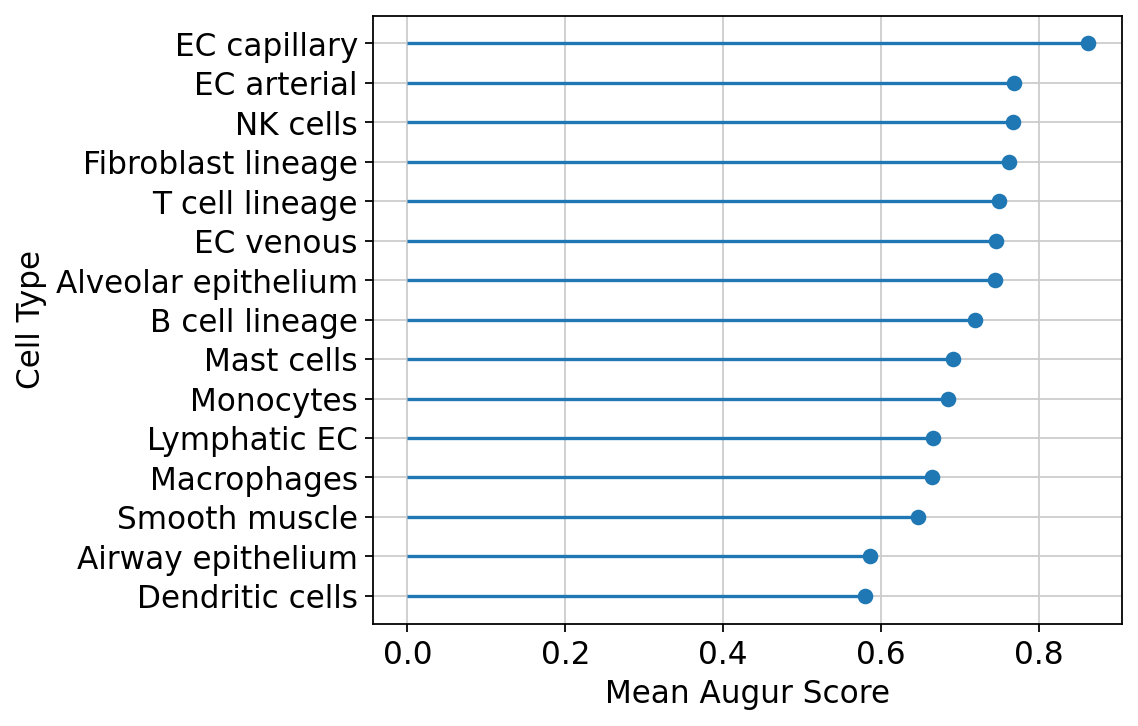

In [15]:
# a lollipop plot showing how well each cell type can distinguish between conditions (e.g., Disease vs Healthy), based on their transcriptional profiles
ag_rfc.plot_lollipop(v_results)  # Just call it, don't assign to a variable

#plt.xlim([0.45, 0.65])
#plt.xticks(np.arange(0.45, 0.65, step=0.05))
plt.grid(False)
#plt.savefig(plot_folder + 'pertpy_progressive_vs_stable_level3.pdf')
plt.close()

computing neighbors


/home/huijuanwang/miniconda3/envs/milopy/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:430: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:19)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:26)


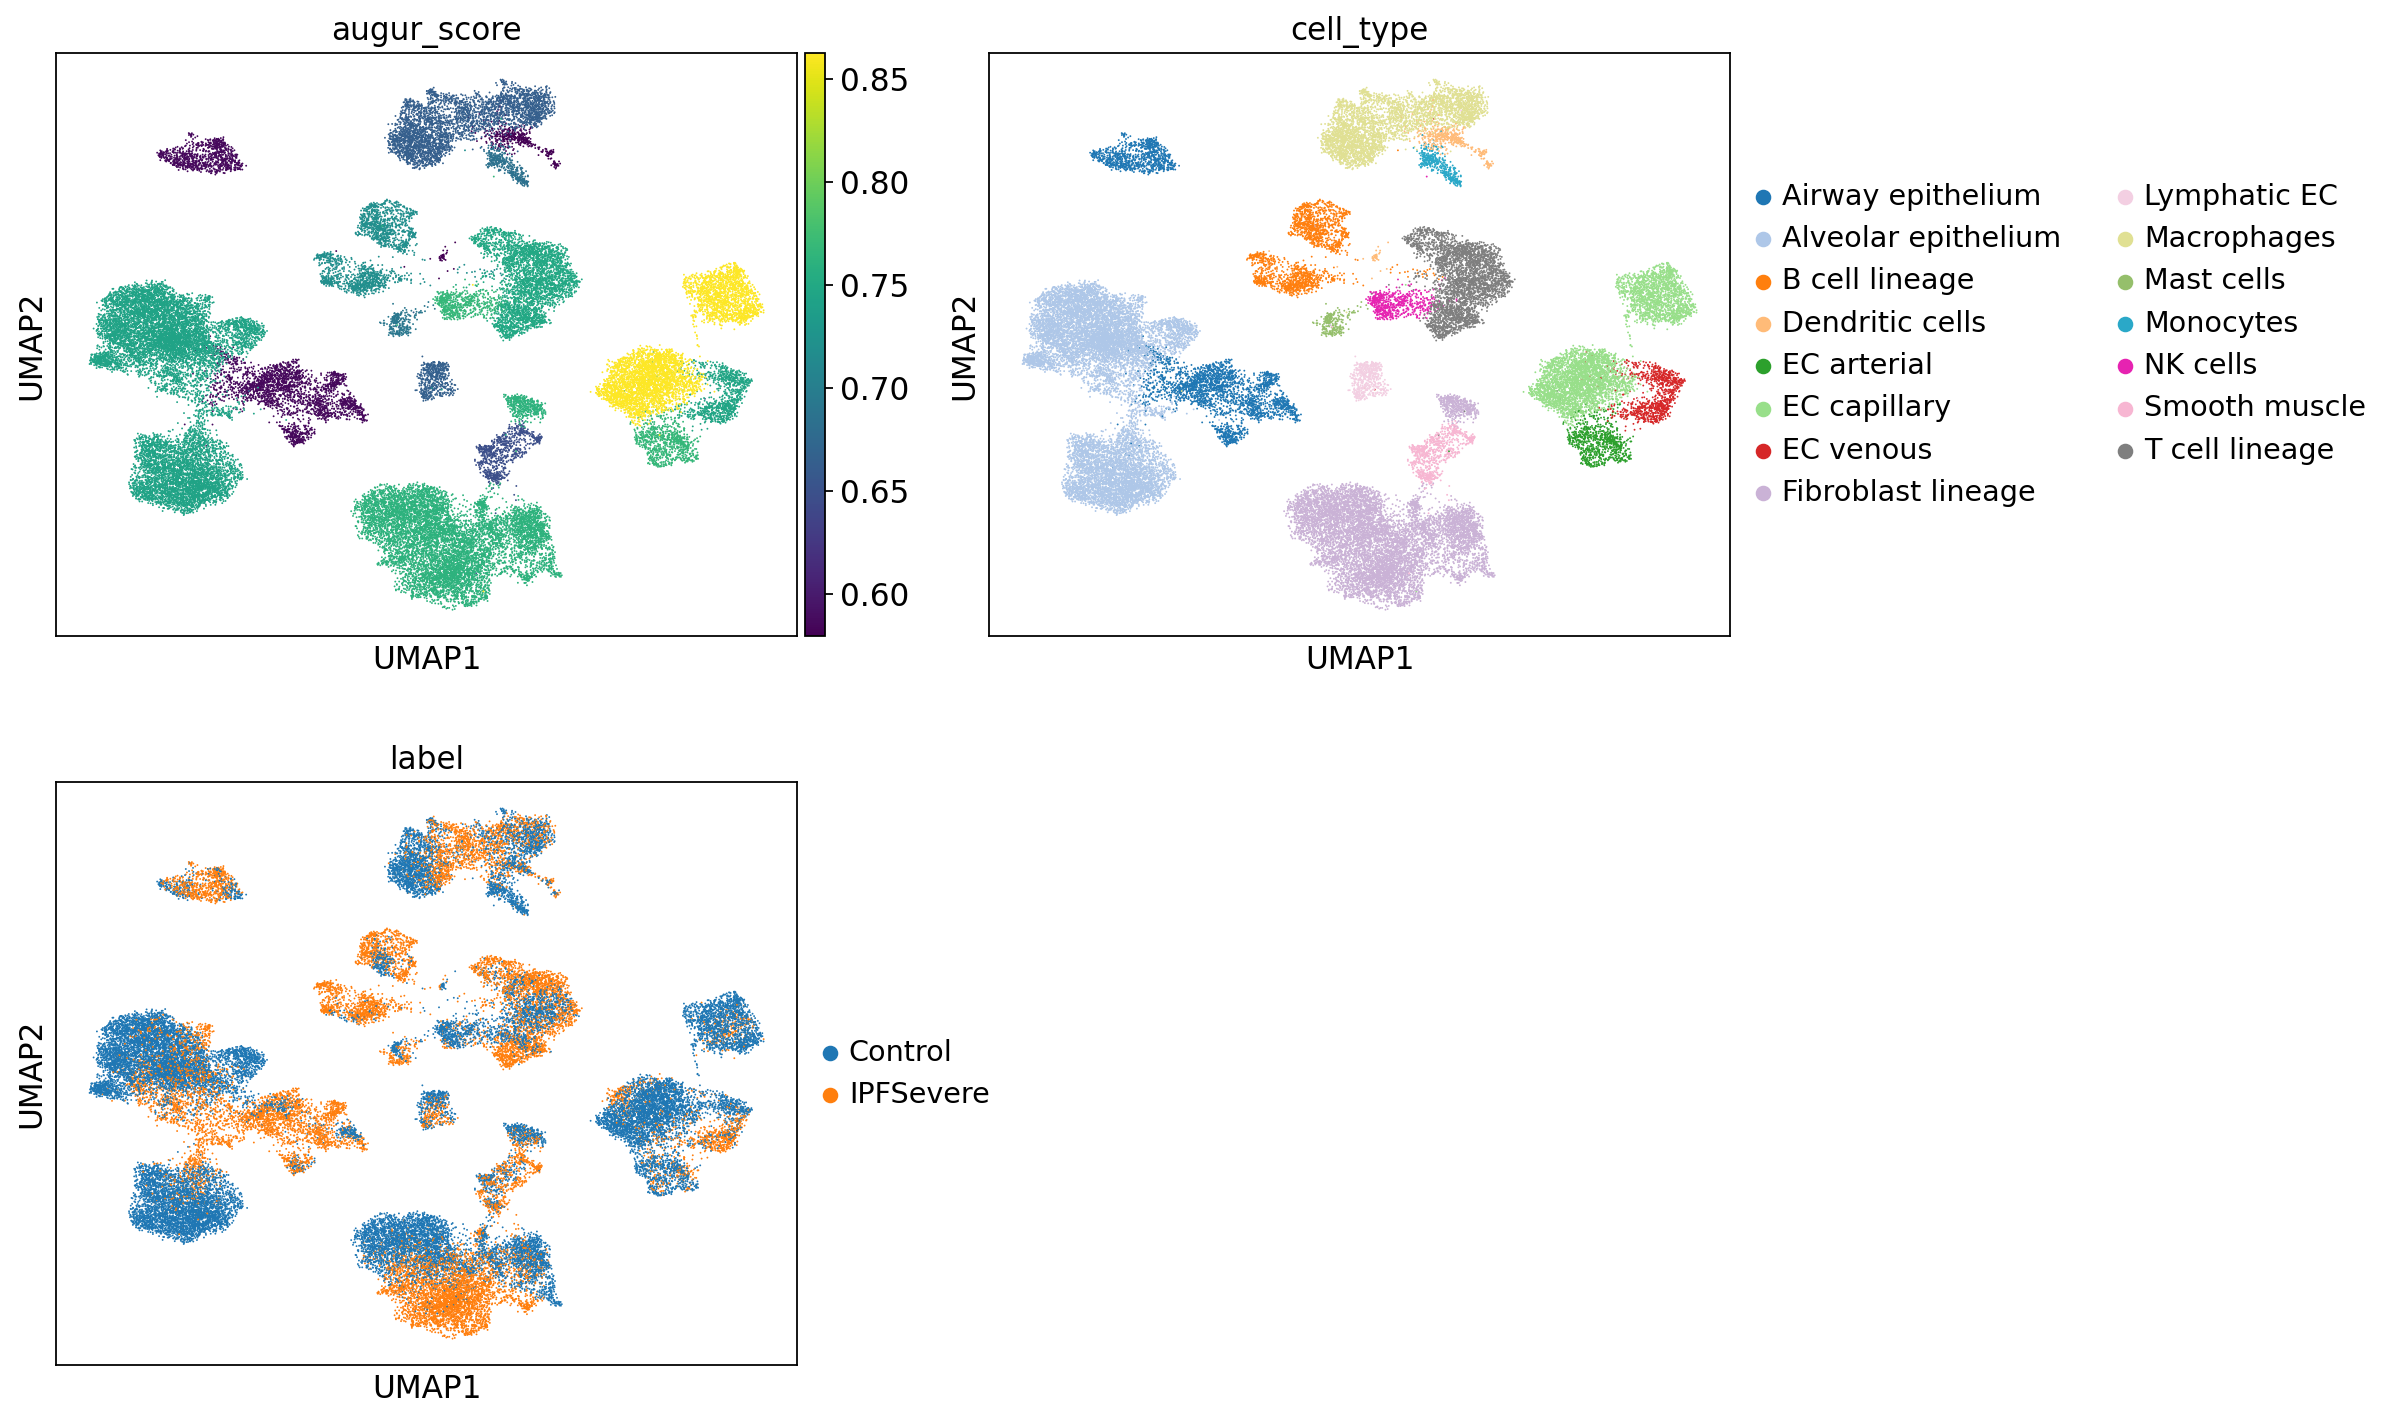

In [16]:
sc.pp.neighbors(v_adata, use_rep="X_scVI")
sc.tl.umap(v_adata)
sc.pl.umap(adata=v_adata, color=["augur_score", "cell_type", "label"], ncols=2)

### write augur score tables

In [17]:
v_scores = v_results['summary_metrics'].loc['mean_augur_score',]

In [18]:
v_scores = pd.DataFrame(v_scores)

In [19]:
## Save the Marker Table
out_folder = "/media/synology/Huijuan/Plots/IPF_subsets/"
v_scores.to_csv(out_folder + "snRNA_IPF_control_severe_augur_scores_level2_all.txt", sep = "\t")